In [ ]:


# # Combine forecast data with original series in .csv file



# plt.figure(figsize=(10, 6))
# plt.plot(df, label='Observed')
# plt.title('SARIMA Forecast')
# plt.xlabel('Date')
# plt.ylabel('Value')
# plt.legend()
# plt.show()

In [59]:
    
from statsmodels.tsa.statespace.sarimax import SARIMAX
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import datetime 


def process_x(x_val: TimeStamp) -> int:
    native = int(x_val.timestamp() * 10**9)/1000000000000000
    return native

def process_x_from_float(x_val: float) -> int:
    native = int(x_val * 10**9)/1000000000000000
    return native
    
def deprocess_x(x_val: int) -> TimeStamp:
    x = (x_val / 10 ** 9) * 1000000000000000
    deprocess = datetime.datetime.utcfromtimestamp(x)
    return deprocess
    
def train_prep_model(data: DataFrame):
    # Load the synthetic data
    
    series = data['Prices']
    
    # Fit SARIMA model
    model = SARIMAX(series, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
    model_fit = model.fit()
    
    # Forecast future values
    forecast = model_fit.forecast(steps=12)

    series_new = data['Prices']

    df = pd.DataFrame(series_new._append(forecast, 
                  ignore_index = False))

    # Combine into two lists
    x = []
    y = []
    for a,b in series_new.items():
        # print("process " + str(a))
        native = process_x(a)
        # print("processed result native " + str(native))
        # deprocessed = deprocess_x(native)
        # print("deprocessed " + str(deprocessed))
        x.append(native)
        y.append(b)        
    
    x = np.array(x)
    y = np.array(y)
    return x,y

In [60]:
def plot_me(x,y, y_fit):
    # Plot the original data, noisy data, and fitted curve
    plt.scatter(x, y, label='Noisy Data')
    plt.plot(x, y, label='Original Data', linestyle='--')
    plt.plot(x, y_fit, label='Fitted Curve')
    plt.legend()
    plt.show()

In [61]:
def interp_y_from_x(input, x, y):
    return np.interp(input, x, y)

def calc_y_fit(x,y):
    # Add some noise to the data
    y_noise = y + np.random.normal(0, 0.03, x.shape)
    
    # Fit a sine curve to the noisy data with a higher degree polynomial
    p = np.polyfit(x, y_noise, 50)
    y_fit = np.polyval(p, x)

    return y_fit




C:\Users\benjp\AppData\Local\Temp\ipykernel_5072\848884939.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data = pd.read_csv('Nat_Gas.csv', index_col='Dates', parse_dates=True)
C:\Dev\jpmc\jpmc\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Dev\jpmc\jpmc\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Dev\jpmc\jpmc\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%

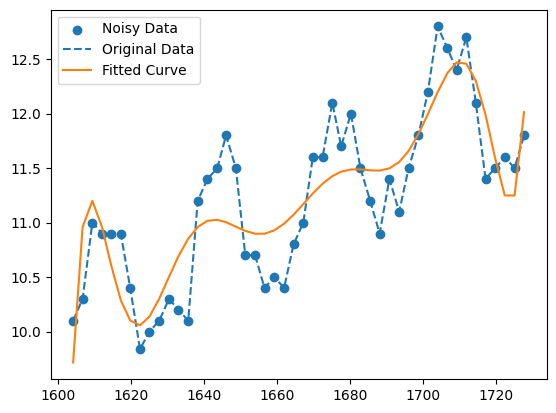

9.71656554599978

In [67]:

def runner(dateIn : str) -> float:
    data = pd.read_csv('Nat_Gas.csv', index_col='Dates', parse_dates=True)
    x,y = train_prep_model(data)
    
    
    y_fit = calc_y_fit(x,y)
    plot_me(x,y, y_fit)
    y = np.array(y_fit)
    
    # y should be sorted for both of these methods
    order = y.argsort()
    y = y[order]
    x = x[order]

    prediction = 0.0
    try:
        dt = datetime.datetime.strptime(dateIn, "%m/%d/%Y")
        res = dt.timestamp()
        res = process_x_from_float(res)
        
        prediction = interp_y_from_x(res, x, y)
    except:
        prediction = 0.0

    return float(prediction)


runner("10/31/2020")

    

